# 🌾 Multimodal Crop Disease Diagnosis
## Wheat Classification: Health / Rust / Other
### Modalities: RGB · Multispectral (5-band) · Hyperspectral (125-band)

In [1]:
import subprocess, sys
pkgs = ["rasterio", "scikit-learn", "tqdm", "matplotlib",
        "seaborn", "pandas", "numpy", "Pillow", "torch", "torchvision"]
for p in pkgs:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
print("All packages ready ✓")

All packages ready ✓


In [2]:
import os, re, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image
import rasterio
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [3]:
# Dataset Paths
BASE   = Path("/home/jyoti/Documents/COMPITION/Kaggle/GreenAid/data")
TRAIN  = BASE / "train"
VAL    = BASE / "val"

TRAIN_RGB = TRAIN / "RGB"
TRAIN_MS  = TRAIN / "MS"
TRAIN_HS  = TRAIN / "HS"
VAL_RGB   = VAL / "RGB"
VAL_MS    = VAL / "MS"
VAL_HS    = VAL / "HS"

CLASSES  = ["Health", "Rust", "Other"]
CLS2IDX  = {c: i for i, c in enumerate(CLASSES)}
IDX2CLS  = {i: c for c, i in CLS2IDX.items()}

# Hyperparameters
IMG_SIZE   = 64
BATCH_SIZE = 32
LR         = 3e-4
EPOCHS     = 15
HS_USEFUL  = slice(10, 111)   # 101 useful bands from 125

print("Paths set ✓")
print("Train MS :", len(list(TRAIN_MS.glob("*.tif"))))
print("Train HS :", len(list(TRAIN_HS.glob("*.tif"))))
print("Val   MS :", len(list(VAL_MS.glob("*.tif"))))

Paths set ✓
Train MS : 600
Train HS : 600
Val   MS : 300


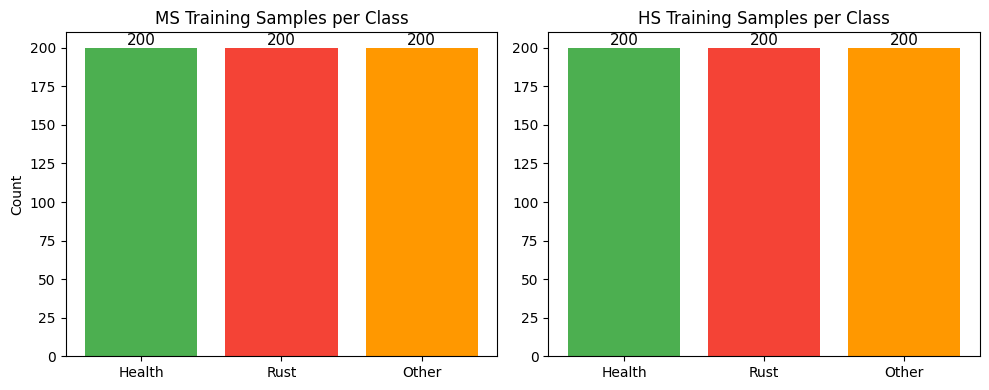

Class distribution: {'Health': 200, 'Rust': 200, 'Other': 200}


In [4]:
# ── Exploratory Data Analysis ────────────────────────────────────────────────
def count_by_class(directory, ext):
    counts = {}
    for cls in CLASSES:
        counts[cls] = len(list(Path(directory).glob(f"{cls}_*.{ext}")))
    return counts

ms_counts = count_by_class(TRAIN_MS, "tif")
hs_counts = count_by_class(TRAIN_HS, "tif")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
colors = ["#4CAF50", "#F44336", "#FF9800"]

ax[0].bar(CLASSES, [ms_counts[c] for c in CLASSES], color=colors)
ax[0].set_title("MS Training Samples per Class"); ax[0].set_ylabel("Count")
ax[1].bar(CLASSES, [hs_counts[c] for c in CLASSES], color=colors)
ax[1].set_title("HS Training Samples per Class")

for a, counts in zip(ax, [ms_counts, hs_counts]):
    for bar, cls in zip(a.patches, CLASSES):
        a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
               str(int(bar.get_height())), ha="center", fontsize=11)

plt.tight_layout(); plt.savefig("class_distribution.png", dpi=100); plt.show()
print("Class distribution:", ms_counts)

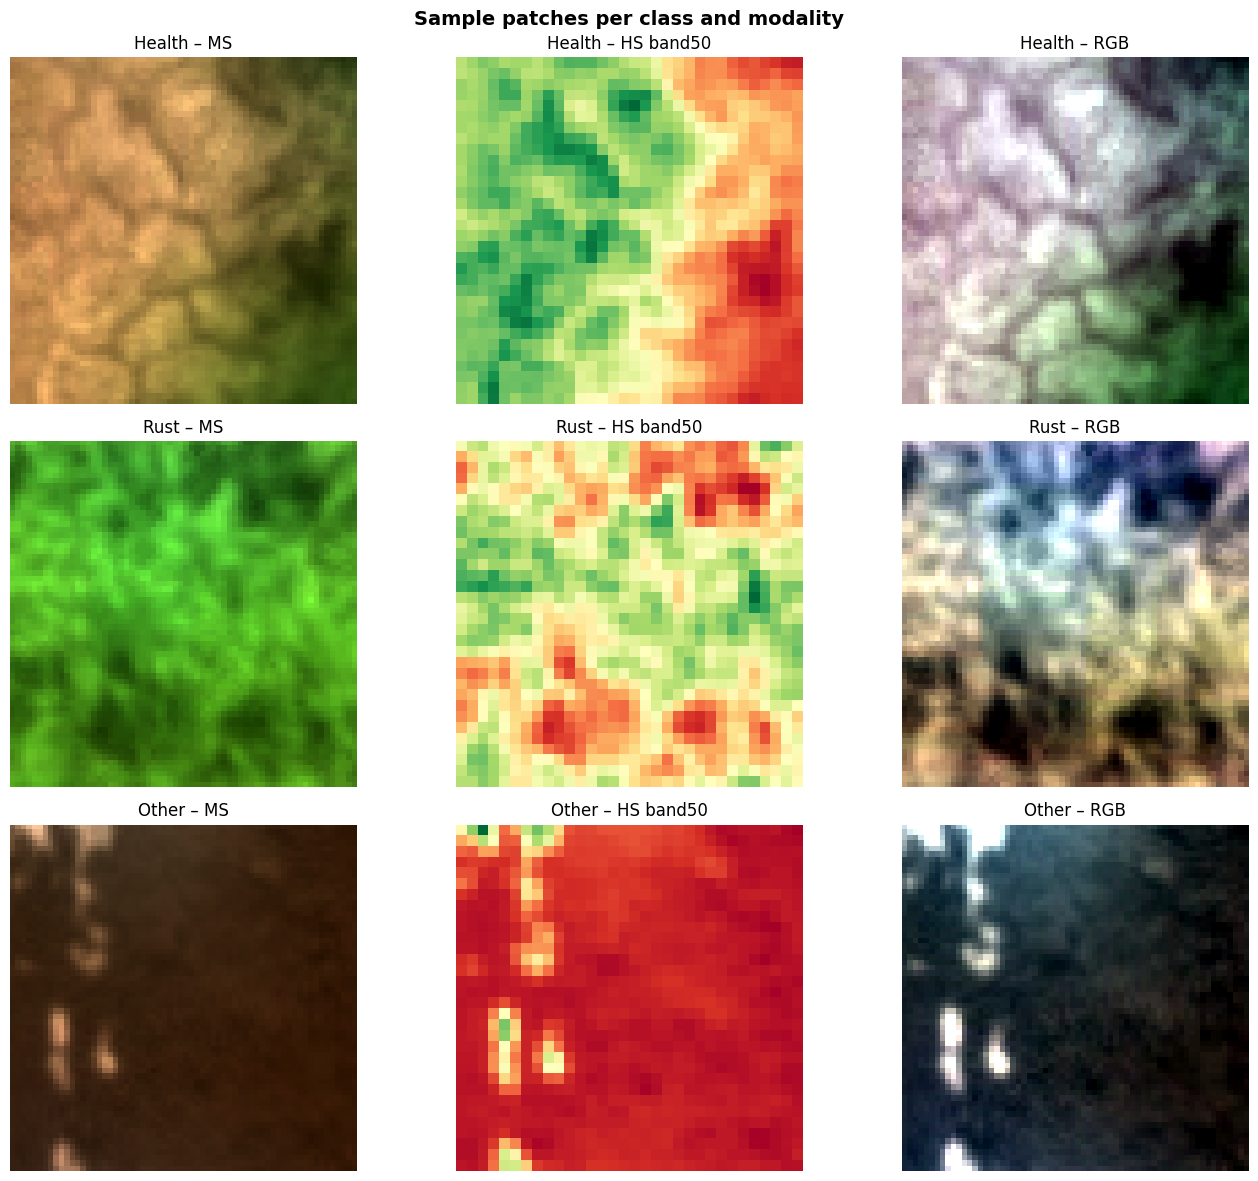

In [5]:
# ── Visualise Sample Images ──────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 12))

for ci, cls in enumerate(CLASSES):
    # MS false-color (bands 2,1,0)
    ms_file = sorted(TRAIN_MS.glob(f"{cls}_*.tif"))[0]
    with rasterio.open(ms_file) as src:
        ms = src.read().astype(np.float32)
    rgb_false = np.stack([ms[2], ms[1], ms[0]], axis=-1)
    rgb_false = (rgb_false - rgb_false.min()) / (rgb_false.max() - rgb_false.min() + 1e-6)
    axes[ci][0].imshow(rgb_false); axes[ci][0].set_title(f"{cls} – MS"); axes[ci][0].axis("off")

    # HS band 50
    hs_file = sorted(TRAIN_HS.glob(f"{cls}_*.tif"))[0]
    with rasterio.open(hs_file) as src:
        hs = src.read().astype(np.float32)
    band = hs[50]; band = (band - band.min()) / (band.max() - band.min() + 1e-6)
    axes[ci][1].imshow(band, cmap="RdYlGn"); axes[ci][1].set_title(f"{cls} – HS band50"); axes[ci][1].axis("off")

    # RGB
    rgb_files = sorted(TRAIN_RGB.glob(f"{cls}_*.png")) if TRAIN_RGB.exists() else []
    if rgb_files:
        img = np.array(Image.open(rgb_files[0]).convert("RGB"))
        axes[ci][2].imshow(img)
    else:
        axes[ci][2].text(0.4, 0.5, "N/A", transform=axes[ci][2].transAxes)
    axes[ci][2].set_title(f"{cls} – RGB"); axes[ci][2].axis("off")

plt.suptitle("Sample patches per class and modality", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.savefig("sample_vis.png", dpi=100); plt.show()

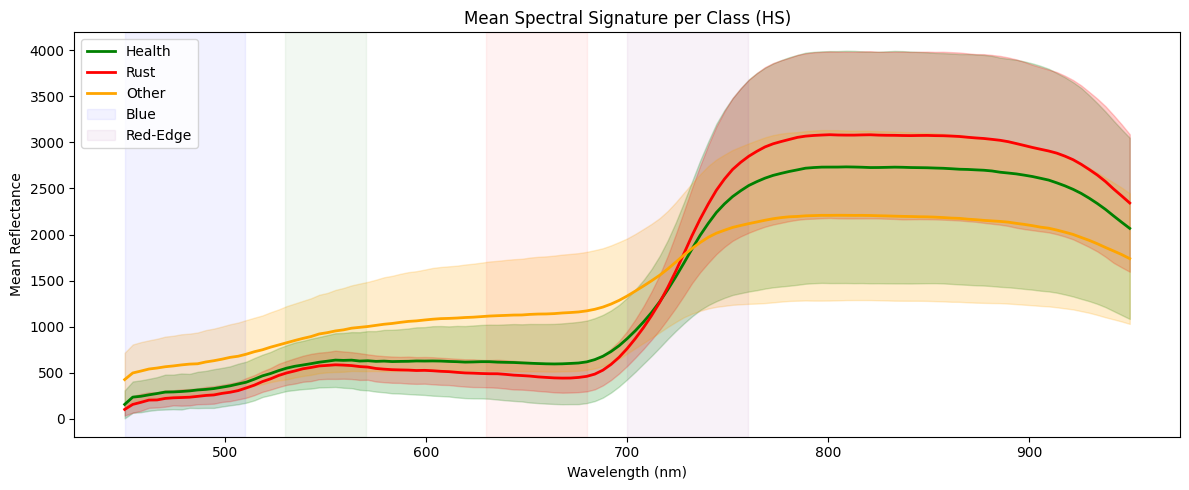

In [6]:
# ── Spectral Signatures ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

for cls, color in zip(CLASSES, ["green", "red", "orange"]):
    spectra, band_counts = [], []
    files = list(TRAIN_HS.glob(f"{cls}_*.tif"))[:20]
    for f in files:
        with rasterio.open(f) as src:
            band_counts.append(src.count)
    min_bands = min(band_counts)
    for f in files:
        with rasterio.open(f) as src:
            data = src.read().astype(np.float32)[:min_bands]
        spectra.append(data.reshape(min_bands, -1).mean(axis=1))
    spectra = np.stack(spectra)
    mean_s, std_s = spectra.mean(axis=0), spectra.std(axis=0)
    wavelengths = np.linspace(450, 950, min_bands)
    ax.plot(wavelengths, mean_s, label=cls, color=color, linewidth=2)
    ax.fill_between(wavelengths, mean_s - std_s, mean_s + std_s, alpha=0.2, color=color)

ax.axvspan(450, 510, alpha=0.05, color="blue", label="Blue")
ax.axvspan(530, 570, alpha=0.05, color="green")
ax.axvspan(630, 680, alpha=0.05, color="red")
ax.axvspan(700, 760, alpha=0.05, color="purple", label="Red-Edge")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Mean Reflectance")
ax.set_title("Mean Spectral Signature per Class (HS)"); ax.legend()
plt.tight_layout(); plt.savefig("spectral_signatures.png", dpi=100); plt.show()

In [7]:
# ── Dataset ──────────────────────────────────────────────────────────────────
class WheatDataset(Dataset):
    """Loads aligned MS + HS tiles. RGB falls back to first 3 MS bands if missing."""

    def __init__(self, ms_dir, hs_dir, rgb_dir=None, img_size=64,
                 augment=False, hs_bands_slice=slice(10, 111)):
        self.ms_dir  = Path(ms_dir)
        self.hs_dir  = Path(hs_dir)
        self.rgb_dir = Path(rgb_dir) if rgb_dir else None
        self.img_size = img_size
        self.augment  = augment
        self.hs_slice = hs_bands_slice
        self.samples  = []

        for cls in CLASSES:
            for ms_f in sorted(self.ms_dir.glob(f"{cls}_*.tif")):
                num = re.search(r"_(\d+)\.tif$", ms_f.name)
                if not num: continue
                n = num.group(1)
                hs_f = self.hs_dir / f"{cls}_hyper_{n}.tif"
                if not hs_f.exists(): continue
                rgb_f = None
                if self.rgb_dir and self.rgb_dir.exists():
                    cands = list(self.rgb_dir.glob(f"{cls}_*{n}.png"))
                    if cands: rgb_f = cands[0]
                self.samples.append((ms_f, hs_f, rgb_f, CLS2IDX[cls]))

        self.rgb_aug = T.Compose([
            T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
        ])

    def __len__(self): return len(self.samples)

    def _read_tif(self, path, bands_slice=None):
        with rasterio.open(path) as src:
            data = src.read().astype(np.float32)
        if bands_slice: data = data[bands_slice]
        mn = data.min(axis=(1,2), keepdims=True)
        mx = data.max(axis=(1,2), keepdims=True)
        return (data - mn) / (mx - mn + 1e-6)

    def _resize(self, x):
        return F.interpolate(x.unsqueeze(0),
                             size=(self.img_size, self.img_size),
                             mode="bilinear", align_corners=False).squeeze(0)

    def __getitem__(self, idx):
        ms_f, hs_f, rgb_f, label = self.samples[idx]

        ms_t = self._resize(torch.from_numpy(self._read_tif(ms_f)))
        hs_t = self._resize(torch.from_numpy(self._read_tif(hs_f, self.hs_slice)))

        if rgb_f:
            img = Image.open(rgb_f).convert("RGB")
            if self.augment: img = self.rgb_aug(img)
            rgb_t = self._resize(torch.from_numpy(
                np.array(img).astype(np.float32).transpose(2,0,1) / 255.))
        else:
            rgb_t = ms_t[:3].clone()

        if self.augment and random.random() > 0.5:
            k = random.randint(1, 3)
            ms_t  = torch.rot90(ms_t,  k, [1,2])
            hs_t  = torch.rot90(hs_t,  k, [1,2])
            rgb_t = torch.rot90(rgb_t, k, [1,2])

        return {"ms": ms_t, "hs": hs_t, "rgb": rgb_t, "label": torch.tensor(label)}

In [8]:
# ── Validation Dataset (unlabelled) ─────────────────────────────────────────
class WheatValDataset(Dataset):
    """Unlabelled validation set for generating submission CSV."""

    def __init__(self, ms_dir, hs_dir, rgb_dir=None, img_size=64,
                 hs_bands_slice=slice(10, 111)):
        self.ms_dir   = Path(ms_dir)
        self.hs_dir   = Path(hs_dir)
        self.rgb_dir  = Path(rgb_dir) if rgb_dir else None
        self.img_size = img_size
        self.hs_slice = hs_bands_slice
        self.ids = sorted([f.stem for f in self.ms_dir.glob("val_*.tif")])

    def __len__(self): return len(self.ids)

    def _read_tif(self, path, bands_slice=None):
        with rasterio.open(path) as src:
            data = src.read().astype(np.float32)
        if bands_slice: data = data[bands_slice]
        mn = data.min(axis=(1,2), keepdims=True)
        mx = data.max(axis=(1,2), keepdims=True)
        return (data - mn) / (mx - mn + 1e-6)

    def _resize(self, t):
        return F.interpolate(t.unsqueeze(0),
                             size=(self.img_size, self.img_size),
                             mode="bilinear", align_corners=False).squeeze(0)

    def __getitem__(self, idx):
        vid = self.ids[idx]
        ms = self._resize(torch.from_numpy(self._read_tif(self.ms_dir / f"{vid}.tif")))
        hs = self._resize(torch.from_numpy(self._read_tif(self.hs_dir / f"{vid}.tif", self.hs_slice)))

        rgb_path = self.rgb_dir / f"{vid}.png" if self.rgb_dir else None
        if rgb_path and rgb_path.exists():
            img = np.array(Image.open(rgb_path).convert("RGB")).astype(np.float32) / 255.
            rgb = self._resize(torch.from_numpy(img.transpose(2,0,1)))
        else:
            rgb = ms[:3].clone()

        return {"ms": ms, "hs": hs, "rgb": rgb, "id": vid}

In [9]:
# ── Simple Multimodal Model ───────────────────────────────────────────────────

class RGBEncoder(nn.Module):
    """Pretrained ResNet-18 backbone, outputs 128-d feature."""
    def __init__(self, out_dim=128):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.features = nn.Sequential(*list(base.children())[:-1])  # strip fc
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        return self.fc(self.features(x).flatten(1))


class MSEncoder(nn.Module):
    """Small CNN for 5-band multispectral input."""
    def __init__(self, in_ch=5, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),    nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, out_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))


class HSEncoder(nn.Module):
    """Small CNN for 101-band hyperspectral input."""
    def __init__(self, bands=101, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(bands, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64,    64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.fc = nn.Linear(64, out_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))


class SimpleFusionNet(nn.Module):
    """Concatenate RGB + MS + HS features → MLP classifier."""
    def __init__(self, n_classes=3):
        super().__init__()
        self.rgb_enc = RGBEncoder(128)
        self.ms_enc  = MSEncoder(5, 128)
        self.hs_enc  = HSEncoder(101, 128)

        self.classifier = nn.Sequential(
            nn.Linear(128 * 3, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, n_classes)
        )

    def forward(self, rgb, ms, hs):
        f = torch.cat([self.rgb_enc(rgb), self.ms_enc(ms), self.hs_enc(hs)], dim=1)
        return self.classifier(f)


model = SimpleFusionNet(n_classes=3).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model: SimpleFusionNet | Trainable params: {total_params:,}")

Model: SimpleFusionNet | Trainable params: 11,473,731


In [10]:
# ── Build DataLoaders ─────────────────────────────────────────────────────────
full_ds = WheatDataset(TRAIN_MS, TRAIN_HS, TRAIN_RGB,
                       img_size=IMG_SIZE, augment=False, hs_bands_slice=HS_USEFUL)
print(f"Total labelled samples: {len(full_ds)}")

n_val = int(0.2 * len(full_ds))
n_tr  = len(full_ds) - n_val
tr_ds, val_ds = random_split(full_ds, [n_tr, n_val],
                             generator=torch.Generator().manual_seed(SEED))

# Re-build train subset with augmentation enabled
aug_ds = WheatDataset(TRAIN_MS, TRAIN_HS, TRAIN_RGB,
                      img_size=IMG_SIZE, augment=True, hs_bands_slice=HS_USEFUL)
aug_ds.samples = [full_ds.samples[i] for i in tr_ds.indices]

tr_loader  = DataLoader(aug_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=4, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train: {len(aug_ds)}  |  Val: {len(val_ds)}")
print(f"Batches – train: {len(tr_loader)}  val: {len(val_loader)}")

Total labelled samples: 600
Train: 480  |  Val: 120
Batches – train: 15  val: 4


In [11]:
# ── Training Setup ───────────────────────────────────────────────────────────
# Class weights to handle imbalance
cls_counts = np.array([len(list(TRAIN_MS.glob(f"{c}_*.tif"))) for c in CLASSES], dtype=float)
class_weights = torch.tensor(cls_counts.sum() / (len(CLASSES) * cls_counts), dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            rgb    = batch["rgb"].to(DEVICE)
            ms     = batch["ms"].to(DEVICE)
            hs     = batch["hs"].to(DEVICE)
            labels = batch["label"].to(DEVICE)

            if train: optimizer.zero_grad()
            logits = model(rgb, ms, hs)
            loss   = criterion(logits, labels)
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += labels.size(0)
    return total_loss / total, correct / total

print("Training setup ready ✓")

Training setup ready ✓


In [12]:
# ── Training Loop ────────────────────────────────────────────────────────────
history = {"tr_loss": [], "tr_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.
SAVE_PATH = "best_model.pt"

for epoch in range(1, EPOCHS + 1):
    tr_loss,  tr_acc  = run_epoch(tr_loader,  train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)
    scheduler.step()

    history["tr_loss"].append(tr_loss);   history["tr_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), SAVE_PATH)
        mark = " ★ saved"
    else:
        mark = ""

    print(f"Ep {epoch:3d}/{EPOCHS} | "
          f"tr_loss={tr_loss:.4f} tr_acc={tr_acc:.3f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}{mark}")

print(f"\nBest val accuracy: {best_val_acc:.4f}")

Ep   1/15 | tr_loss=1.0150 tr_acc=0.477 | val_loss=0.8803 val_acc=0.575 ★ saved
Ep   2/15 | tr_loss=0.7961 tr_acc=0.633 | val_loss=0.9693 val_acc=0.525
Ep   3/15 | tr_loss=0.7311 tr_acc=0.658 | val_loss=0.7474 val_acc=0.650 ★ saved
Ep   4/15 | tr_loss=0.7085 tr_acc=0.708 | val_loss=0.7458 val_acc=0.625
Ep   5/15 | tr_loss=0.6107 tr_acc=0.729 | val_loss=0.8490 val_acc=0.625
Ep   6/15 | tr_loss=0.5632 tr_acc=0.785 | val_loss=0.7365 val_acc=0.667 ★ saved
Ep   7/15 | tr_loss=0.4659 tr_acc=0.812 | val_loss=0.7041 val_acc=0.667
Ep   8/15 | tr_loss=0.4019 tr_acc=0.852 | val_loss=0.7448 val_acc=0.683 ★ saved
Ep   9/15 | tr_loss=0.3561 tr_acc=0.858 | val_loss=0.7319 val_acc=0.700 ★ saved
Ep  10/15 | tr_loss=0.3928 tr_acc=0.846 | val_loss=0.7649 val_acc=0.708 ★ saved
Ep  11/15 | tr_loss=0.3247 tr_acc=0.885 | val_loss=0.7295 val_acc=0.658
Ep  12/15 | tr_loss=0.3366 tr_acc=0.873 | val_loss=0.6806 val_acc=0.725 ★ saved
Ep  13/15 | tr_loss=0.2456 tr_acc=0.904 | val_loss=0.6965 val_acc=0.725
Ep  14/1

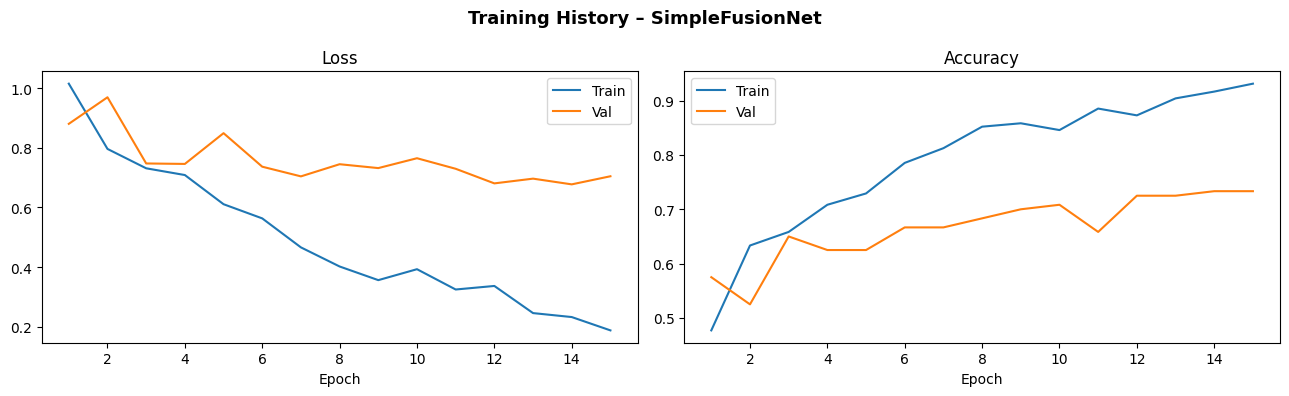

In [13]:
# ── Training Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, EPOCHS + 1)

axes[0].plot(ep, history["tr_loss"], label="Train")
axes[0].plot(ep, history["val_loss"], label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(ep, history["tr_acc"], label="Train")
axes[1].plot(ep, history["val_acc"], label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.suptitle("Training History – SimpleFusionNet", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("training_curves.png", dpi=100); plt.show()

              precision    recall  f1-score   support

      Health       0.69      0.73      0.71        45
        Rust       0.65      0.63      0.64        41
       Other       0.91      0.85      0.88        34

    accuracy                           0.73       120
   macro avg       0.75      0.74      0.74       120
weighted avg       0.74      0.73      0.73       120



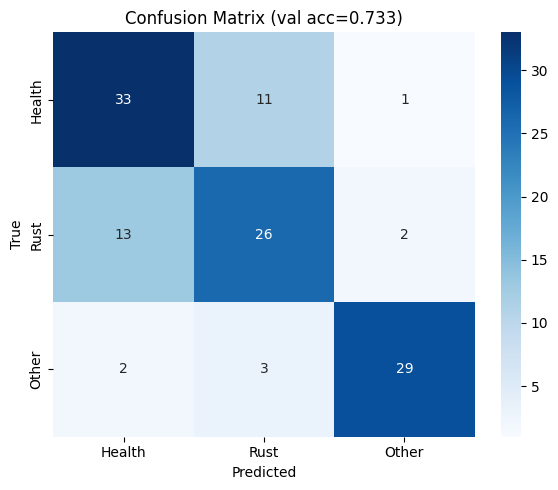

In [14]:
# ── Detailed Evaluation ──────────────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in val_loader:
        logits = model(batch["rgb"].to(DEVICE), batch["ms"].to(DEVICE), batch["hs"].to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(batch["label"].numpy())

print(classification_report(all_labels, all_preds, target_names=CLASSES))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix (val acc={accuracy_score(all_labels, all_preds):.3f})")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=100); plt.show()

In [15]:
# ── Generate Submission CSV ───────────────────────────────────────────────────
test_ds     = WheatValDataset(VAL_MS, VAL_HS, VAL_RGB, img_size=IMG_SIZE, hs_bands_slice=HS_USEFUL)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

model.eval()
rows = []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Predicting"):
        logits = model(batch["rgb"].to(DEVICE), batch["ms"].to(DEVICE), batch["hs"].to(DEVICE))
        preds  = logits.argmax(1).cpu().numpy()
        for vid, pred in zip(batch["id"], preds):
            rows.append({"Id": vid + ".tif", "Category": IDX2CLS[pred]})

sub = pd.DataFrame(rows).sort_values("Id").reset_index(drop=True)
sub.to_csv("submission.csv", index=False)
print(f"Saved submission.csv  ({len(sub)} rows)")
print(sub["Category"].value_counts())
sub.head(10)

Predicting:   0%|          | 0/10 [00:00<?, ?it/s]

Saved submission.csv  (300 rows)
Category
Rust      116
Health     97
Other      87
Name: count, dtype: int64


,Id,Category
0,val_000a83c1.tif,Other
1,val_00a704b1.tif,Other
2,val_01dde030.tif,Health
3,val_024df365.tif,Rust
4,val_02afcb0e.tif,Health
5,val_03864ba6.tif,Rust
6,val_0537e324.tif,Health
7,val_059983e0.tif,Rust
8,val_05cee914.tif,Other
9,val_07af871a.tif,Rust


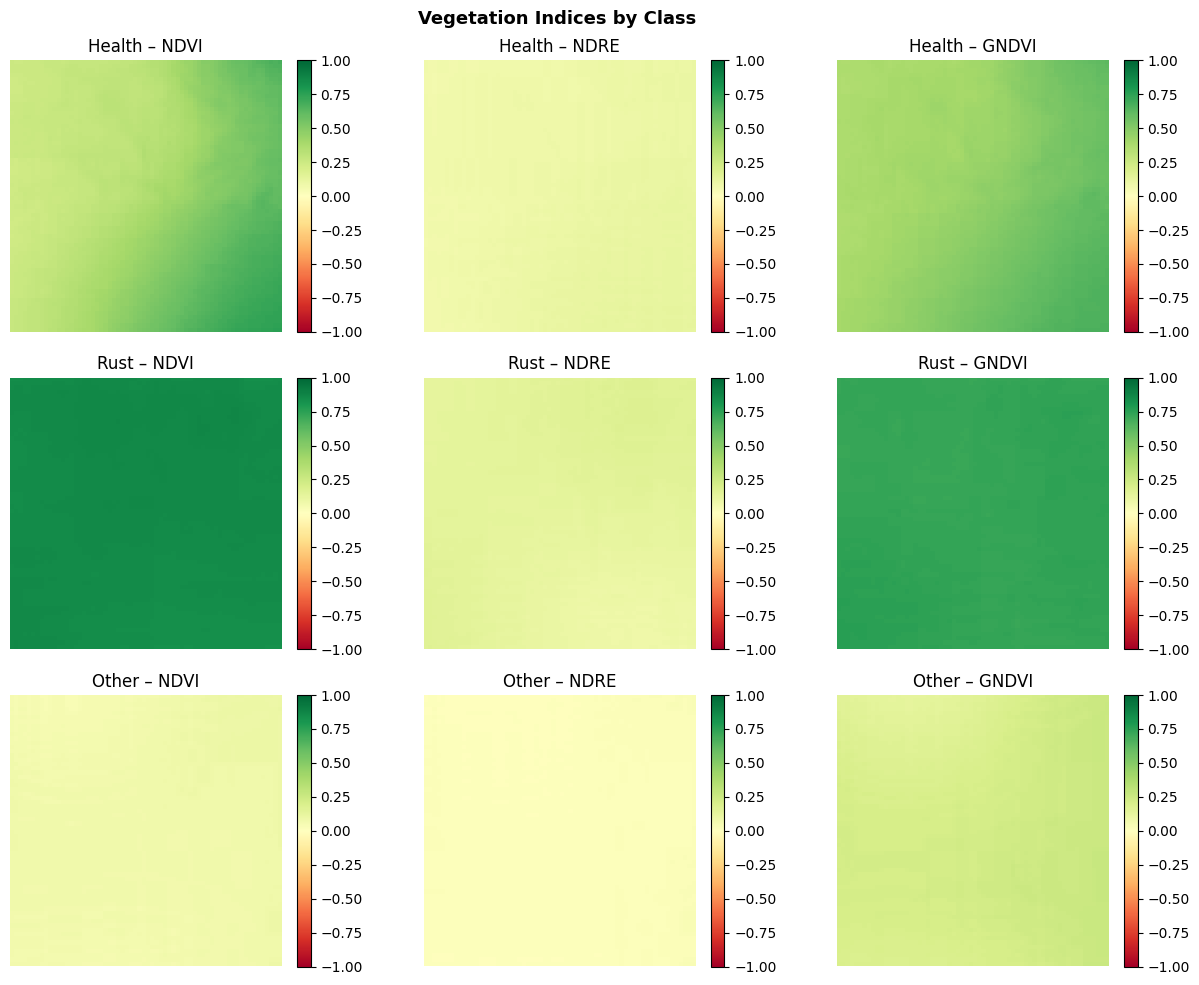

In [16]:
# ── Vegetation Indices from MS Bands ─────────────────────────────────────────
# Band order: B(0), G(1), R(2), RE(3), NIR(4)
def compute_vi(ms_arr):
    B, G, R, RE, NIR = [ms_arr[i] for i in range(5)]
    eps = 1e-6
    return {
        "NDVI":  (NIR - R)  / (NIR + R  + eps),
        "NDRE":  (NIR - RE) / (NIR + RE + eps),
        "GNDVI": (NIR - G)  / (NIR + G  + eps),
    }

fig, axes = plt.subplots(3, 3, figsize=(13, 10))
for ci, cls in enumerate(CLASSES):
    f = sorted(TRAIN_MS.glob(f"{cls}_*.tif"))[0]
    with rasterio.open(f) as src:
        ms = src.read().astype(np.float32)
    vis = compute_vi(ms)
    for ji, (vname, vdata) in enumerate(vis.items()):
        im = axes[ci][ji].imshow(vdata, cmap="RdYlGn", vmin=-1, vmax=1)
        axes[ci][ji].set_title(f"{cls} – {vname}"); axes[ci][ji].axis("off")
        plt.colorbar(im, ax=axes[ci][ji], fraction=0.046, pad=0.04)

plt.suptitle("Vegetation Indices by Class", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("vegetation_indices.png", dpi=100); plt.show()